# MSCS 634 Lab 1

Student: Sebastian C

Course: MSCS 634

Lab Assignment: Lab 1

This lab demonstrates data visualization, preprocessing techniques, and statistical analysis using Python.

In [29]:
import pandas as pd

In [30]:
df = pd.read_csv('datasets/Sample - Superstore.csv', encoding='latin1')

In [31]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Step 2: Data Visualization

In this section, visualizations are used to explore patterns, distributions, and relationships within the dataset.

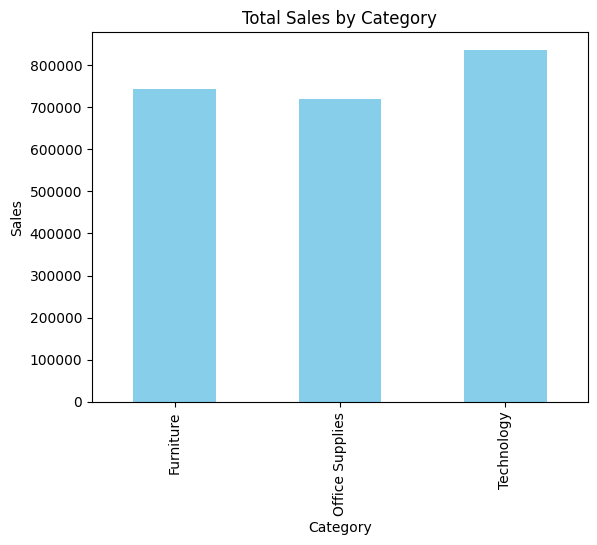

In [32]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', color='skyblue')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

### Insight from Bar Chart

The bar chart shows total sales across product categories. Technology and Office Supplies generate higher sales compared to Furniture, indicating stronger customer demand in those categories.

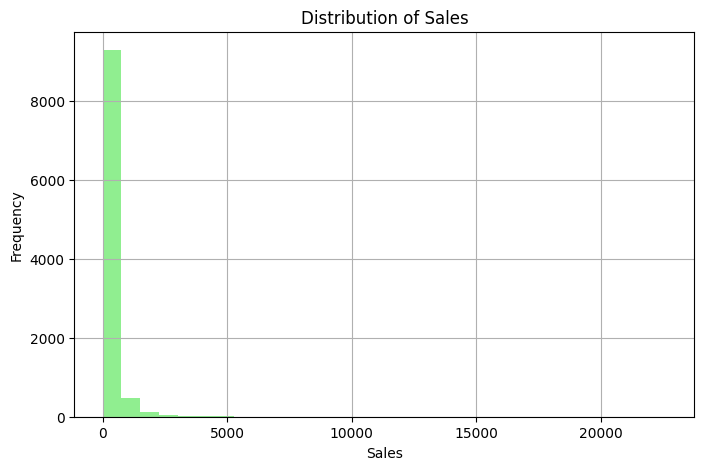

In [33]:
plt.figure(figsize=(8,5))

df['Sales'].hist(bins=30, color='lightgreen')

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

### Insight from Histogram

The histogram shows that most sales transactions are relatively small, while a smaller number of transactions have very large sales amounts. This indicates a right-skewed distribution.

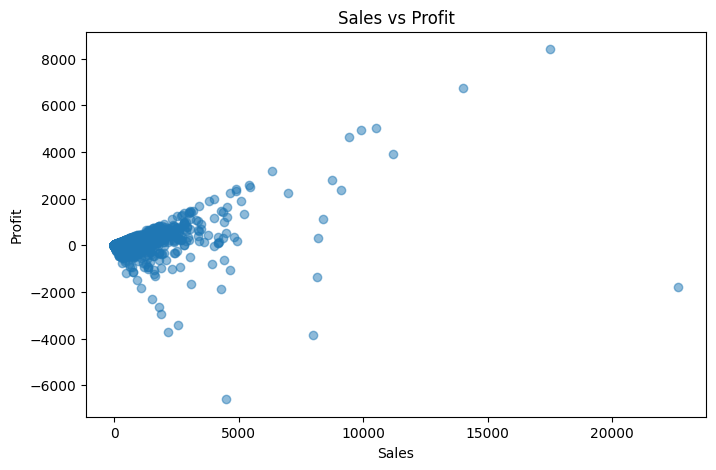

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(df['Sales'], df['Profit'], alpha=0.5)

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()


The scatter plot suggests a positive relationship between sales and profit. However, some transactions show high sales with low or negative profit, indicating that larger sales do not always result in higher profitability.

In [35]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [36]:
df['Postal Code'] = df['Postal Code'].fillna(0)

In [37]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [38]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Q1 = 17.28
Q3 = 209.94
IQR = 192.66
Lower Bound = -271.71000000000004
Upper Bound = 498.93


In [39]:
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

outliers.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
11,12,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,4,0.20,68.3568


In [40]:
df_no_outliers = df[
    (df['Sales'] >= lower_bound) &
    (df['Sales'] <= upper_bound)
]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_no_outliers.shape)

Original Shape: (9994, 21)
After Removing Outliers: (8827, 21)


The IQR method was used to identify outliers in the Sales column. Records outside the lower and upper bounds were treated as outliers and removed from the dataset.

In [41]:
df_no_outliers.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [42]:
sample_df = df_no_outliers.sample(frac=0.5, random_state=42)

reduced_df = sample_df.drop(
    columns=['Row ID', 'Customer ID']
)

reduced_df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1152,CA-2017-160395,12/31/2016,1/6/2017,Standard Class,Kelly Lampkin,Corporate,United States,Reno,Nevada,89502,West,OFF-AR-10003759,Office Supplies,Art,"Crayola Anti Dust Chalk, 12/Pack",3.640,2,0.0,1.6380
9016,CA-2016-131639,12/17/2016,12/23/2016,Standard Class,Noel Staavos,Corporate,United States,Carlsbad,New Mexico,88220,West,OFF-BI-10000948,Office Supplies,Binders,"GBC Laser Imprintable Binding System Covers, D...",11.416,1,0.2,3.8529
6910,US-2017-115301,7/29/2017,8/2/2017,Standard Class,Vivek Gonzalez,Consumer,United States,Seattle,Washington,98103,West,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",115.960,2,0.0,25.5112
7043,US-2017-165358,7/18/2017,7/23/2017,Standard Class,Seth Vernon,Consumer,United States,Philadelphia,Pennsylvania,19134,East,FUR-CH-10002647,Furniture,Chairs,"Situations Contoured Folding Chairs, 4/Set",198.744,4,0.3,-14.1960
7512,US-2017-161935,7/14/2017,7/18/2017,Standard Class,John Lee,Consumer,United States,Columbus,Ohio,43229,East,OFF-ST-10001837,Office Supplies,Storage,"SAFCO Mobile Desk Side File, Wire Frame",239.456,7,0.2,17.9592


Data reduction was performed by selecting 50% of the records and removing identifier columns that were not required for analysis.

In [43]:
from sklearn.preprocessing import MinMaxScaler

In [44]:
reduced_df[['Sales']].head()

,Sales
1152,3.640
9016,11.416
6910,115.960
7043,198.744
7512,239.456


In [45]:
scaler = MinMaxScaler()

reduced_df['Sales_Scaled'] = scaler.fit_transform(
    reduced_df[['Sales']]
)

reduced_df[['Sales', 'Sales_Scaled']].head()

,Sales,Sales_Scaled
1152,3.640,0.006205
9016,11.416,0.021849
6910,115.960,0.232176
7043,198.744,0.398725
7512,239.456,0.480632


Min-Max Scaling transformed Sales values into a range between 0 and 1, making the data easier to compare.

In [46]:
reduced_df['Sales_Category'] = pd.cut(
    reduced_df['Sales'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

reduced_df[['Sales', 'Sales_Category']].head()

,Sales,Sales_Category
1152,3.640,Low
9016,11.416,Low
6910,115.960,Low
7043,198.744,Medium
7512,239.456,Medium


Sales values were grouped into Low, Medium, and High categories to simplify analysis and interpretation.


# Step 4: Statistical Analysis

This section explores the dataset using descriptive statistics, measures of central tendency, measures of dispersion, and correlation analysis.

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [49]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


The dataset contains both numerical and categorical variables. The descriptive statistics provide an overview of the distribution, averages, and spread of numerical attributes such as Sales, Quantity, Discount, and Profit.

In [50]:
print("Minimum:", df['Sales'].min())
print("Maximum:", df['Sales'].max())
print("Mean:", df['Sales'].mean())
print("Median:", df['Sales'].median())
print("Mode:", df['Sales'].mode()[0])

Minimum: 0.444
Maximum: 22638.48
Mean: 229.85800083049833
Median: 54.489999999999995
Mode: 12.96


The mean, median, and mode were calculated for the Sales column. These values provide insight into the typical sales amount and help identify differences between average and most common sales values.

In [51]:
sales_range = df['Sales'].max() - df['Sales'].min()

Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

variance = df['Sales'].var()
std_dev = df['Sales'].std()

print("Range:", sales_range)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Variance:", variance)
print("Standard Deviation:", std_dev)

Range: 22638.036
Q1: 17.28
Q3: 209.94
IQR: 192.66
Variance: 388434.4553080756
Standard Deviation: 623.2451005086807


Measures of dispersion describe the spread of sales values. The range and IQR indicate the distribution width, while variance and standard deviation show how much individual sales values differ from the average.

In [52]:
numeric_df = df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

correlation_matrix

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


The correlation matrix shows the relationships between numerical variables. Positive values indicate variables that increase together, while negative values indicate inverse relationships. Sales and Profit show a positive relationship, although the strength may vary.